In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [24]:
import importlib
import forecasting_utils

importlib.reload(forecasting_utils)

from sklearn.linear_model import PoissonRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

from forecasting_utils import (
    FOCUS_AGES,
    add_lag_features,
    build_daily_arrivals,
    clean_opossum_data,
    evaluate_regression,
    feature_columns,
    forecast_date_range,
    save_csv,
)

## Local Helpers

A couple of these are only here because they are specific to this modeling setup.


In [25]:
from dataclasses import dataclass
@dataclass(frozen=True)
class SplitData:
    train: pd.DataFrame
    validation: pd.DataFrame
    test: pd.DataFrame

In [26]:
def split_for_2026_forecast(df: pd.DataFrame, validation_start: str = "2025-01-01", test_start: str = "2026-01-01") -> SplitData:
    validation_start_ts = pd.Timestamp(validation_start)
    test_start_ts = pd.Timestamp(test_start)

    train = df.loc[df["admission_date"] < validation_start_ts].copy()
    validation = df.loc[
        (df["admission_date"] >= validation_start_ts)
        & (df["admission_date"] < test_start_ts)
        ].copy()
    test = df.loc[df["admission_date"] >= test_start_ts].copy()

    return SplitData(train=train, validation=validation, test=test)

Simple baseline: average arrivals for each month/day combo


In [27]:
def month_day_baseline(train_df: pd.DataFrame, forecast_df: pd.DataFrame) -> np.ndarray:
    reference = (
        train_df.assign(month=train_df["admission_date"].dt.month, day=train_df["admission_date"].dt.day)
        .groupby(["month", "day"])["arrivals"]
        .mean()
    )
    keyed = forecast_df.assign(
        month=forecast_df["admission_date"].dt.month,
        day=forecast_df["admission_date"].dt.day,
    )
    overall_mean = float(train_df["arrivals"].mean())
    return keyed.set_index(["month", "day"]).index.to_series().map(reference).fillna(overall_mean).to_numpy()

In [28]:
def recursive_forecast(model, history_df: pd.DataFrame, forecast_dates, features: list[str], target_col: str = "arrivals") -> pd.DataFrame:
    history = history_df[["admission_date", target_col]].copy()
    history["admission_date"] = pd.to_datetime(history["admission_date"])

    forecast_rows = []
    for forecast_date in pd.to_datetime(list(forecast_dates)):
        candidate = pd.concat(
            [history, pd.DataFrame({"admission_date": [forecast_date], target_col: [np.nan]})],
            ignore_index=True,
        )
        candidate = forecasting_utils.add_calendar_features(candidate)
        candidate = add_lag_features(candidate, target_col=target_col)
        row = candidate.iloc[[-1]].copy()
        prediction = float(model.predict(row[features])[0])
        row[target_col] = prediction
        history = pd.concat([history, row[["admission_date", target_col]]], ignore_index=True)
        forecast_rows.append(row)

    if not forecast_rows:
        return pd.DataFrame(columns=["admission_date", target_col] + features)

    return pd.concat(forecast_rows, ignore_index=True)

In [29]:
def zero_out_period(df: pd.DataFrame, columns, date_col: str = "admission_date", start_date=None, end_date=None, before_month_day: tuple[int, int] | None = (3, 14)) -> pd.DataFrame:
    if before_month_day is None and (start_date is None or end_date is None):
        raise ValueError("Provide either start_date and end_date, or before_month_day.")

    out = df.copy()
    dates = pd.to_datetime(out[date_col])

    if start_date is not None and end_date is not None:
        mask = (dates >= pd.Timestamp(start_date)) & (dates <= pd.Timestamp(end_date))
    elif before_month_day is not None:
        start_month, start_day = before_month_day
        mask = (dates.dt.month < start_month) | ((dates.dt.month == start_month) & (dates.dt.day < start_day))
    else:
        raise ValueError("Could not determine which dates to zero out.")

    for column in columns:
        out.loc[mask, column] = 0.0

    return out

# Statistical Modeling  

This notebook is the baseline-heavy part of the project. I wanted a few simple statistical approaches in the mix before jumping straight into more feature-heavy models.

Basically: start with the obvious stuff, see how far it gets me, then use that as a reality check for everything that comes after.


In [30]:
df = clean_opossum_data()
forecast_end_date = pd.Timestamp("2026-06-01")
daily_df = build_daily_arrivals(df, focus_ages=FOCUS_AGES)
observed_end_date = daily_df["admission_date"].max()
future_horizon_days = max(0, (forecast_end_date - observed_end_date).days)
future_dates = forecast_date_range(observed_end_date, future_horizon_days)
future_frame = pd.DataFrame({"admission_date": future_dates, "arrivals": np.nan})

daily_df.tail()

,admission_date,arrivals,year,quarter,month,day,day_of_week,day_of_year,week_of_year,is_weekend,is_holiday,month_sin,month_cos,dow_sin,dow_cos
9502,2026-04-07,0,2026,2,4,7,1,97,15,0,0,0.866025,-0.5,0.781831,0.623490
9503,2026-04-08,0,2026,2,4,8,2,98,15,0,0,0.866025,-0.5,0.974928,-0.222521
9504,2026-04-09,0,2026,2,4,9,3,99,15,0,0,0.866025,-0.5,0.433884,-0.900969
9505,2026-04-10,0,2026,2,4,10,4,100,15,0,0,0.866025,-0.5,-0.433884,-0.900969
9506,2026-04-11,0,2026,2,4,11,5,101,15,1,0,0.866025,-0.5,-0.974928,-0.222521


In [31]:
model_df = add_lag_features(daily_df).dropna().reset_index(drop=True)
splits = split_for_2026_forecast(model_df)
features = feature_columns(model_df)

X_train = splits.train[features]
y_train = splits.train["arrivals"]
X_valid = splits.validation[features]
y_valid = splits.validation["arrivals"]
X_test = splits.test[features]
y_test = splits.test["arrivals"]

In [32]:
baseline_valid_pred = month_day_baseline(splits.train, splits.validation)
baseline_test_pred = month_day_baseline(
    pd.concat([splits.train, splits.validation], ignore_index=True),
    splits.test,
)
baseline_test_pred = zero_out_period(
    splits.test[["admission_date"]].assign(baseline_pred=baseline_test_pred),
    ["baseline_pred"],
)["baseline_pred"].to_numpy()

baseline_metrics = pd.DataFrame(
    [
        evaluate_regression(y_valid, baseline_valid_pred, "Month-Day Baseline (2025 validation)"),
        evaluate_regression(y_test, baseline_test_pred, "Month-Day Baseline (2026 test)"),
    ]
)
baseline_metrics

,model,mae,rmse,mape
0,Month-Day Baseline (2025 validation),1.859046,3.924487,67.683316
1,Month-Day Baseline (2026 test),0.090297,0.501941,98.000000


In [33]:
poisson = PoissonRegressor(alpha=0.2, max_iter=3000)
poisson.fit(X_train, y_train)

poisson_valid_pred = poisson.predict(X_valid)
poisson_test_pred = poisson.predict(X_test)
poisson_test_pred = zero_out_period(
    splits.test[["admission_date"]].assign(poisson_pred=poisson_test_pred),
    ["poisson_pred"],
)["poisson_pred"].to_numpy()

poisson_metrics = pd.DataFrame(
    [
        evaluate_regression(y_valid, poisson_valid_pred, "PoissonRegressor (2025 validation)"),
        evaluate_regression(y_test, poisson_test_pred, "PoissonRegressor (2026 test)"),
    ]
)
poisson_metrics

C:\Users\Owner\PycharmProjects\opos_prediction\opos_prediction\Lib\site-packages\sklearn\linear_model\_glm\glm.py:290: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result(


,model,mae,rmse,mape
0,PoissonRegressor (2025 validation),1.988470,3.709722,92.439094
1,PoissonRegressor (2026 test),0.186841,0.537021,96.650029


In [34]:
sarimax_train = pd.concat([splits.train, splits.validation], ignore_index=True)
sarimax_model = SARIMAX(
    sarimax_train["arrivals"],
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_results = sarimax_model.fit(disp=False)

sarimax_forecast = sarimax_results.forecast(steps=len(splits.test))
sarimax_forecast = zero_out_period(
    splits.test[["admission_date"]].assign(sarimax_pred=sarimax_forecast.to_numpy()),
    ["sarimax_pred"],
)["sarimax_pred"]
sarimax_metrics = pd.DataFrame(
    [evaluate_regression(y_test.reset_index(drop=True), sarimax_forecast.to_numpy(), "SARIMAX (2026 test)")]
)
sarimax_metrics

,model,mae,rmse,mape
0,SARIMAX (2026 test),0.360679,0.714002,87.760886


## Validation And Test Metrics

This table is the quick scoreboard. I'm mostly looking at whether the simple baseline holds up and whether Poisson or SARIMAX actually earns the extra complexity.


In [35]:
stat_results = pd.concat([baseline_metrics, poisson_metrics, sarimax_metrics], ignore_index=True)
stat_results.sort_values(["rmse", "mae"])

,model,mae,rmse,mape
1,Month-Day Baseline (2026 test),0.090297,0.501941,98.000000
3,PoissonRegressor (2026 test),0.186841,0.537021,96.650029
4,SARIMAX (2026 test),0.360679,0.714002,87.760886
2,PoissonRegressor (2025 validation),1.988470,3.709722,92.439094
0,Month-Day Baseline (2025 validation),1.859046,3.924487,67.683316


In [36]:
baseline_future_pred = month_day_baseline(model_df, future_frame)
baseline_future_pred = zero_out_period(
    future_frame[["admission_date"]].assign(baseline_pred=baseline_future_pred),
    ["baseline_pred"],
)["baseline_pred"].to_numpy()

In [37]:
poisson_full = PoissonRegressor(alpha=0.2, max_iter=3000)
poisson_full.fit(model_df[features], model_df["arrivals"])
poisson_future_rows = recursive_forecast(poisson_full, daily_df, future_dates, features)
poisson_future_pred = zero_out_period(
    poisson_future_rows[["admission_date"]].assign(poisson_pred=poisson_future_rows["arrivals"].to_numpy()),
    ["poisson_pred"],
)["poisson_pred"].to_numpy()

C:\Users\Owner\PycharmProjects\opos_prediction\opos_prediction\Lib\site-packages\sklearn\linear_model\_glm\glm.py:290: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result(


In [38]:
sarimax_full_model = SARIMAX(
    daily_df["arrivals"],
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

In [39]:
sarimax_full_results = sarimax_full_model.fit(disp=False)
sarimax_future_pred = sarimax_full_results.forecast(steps=len(future_dates))
sarimax_future_pred = zero_out_period(
    future_frame[["admission_date"]].assign(sarimax_pred=np.asarray(sarimax_future_pred)),
    ["sarimax_pred"],
)["sarimax_pred"].to_numpy()

In [40]:
observed_comparison = splits.test[["admission_date", "arrivals"]].copy()
observed_comparison["baseline_pred"] = baseline_test_pred
observed_comparison["poisson_pred"] = poisson_test_pred
observed_comparison["sarimax_pred"] = sarimax_forecast.to_numpy()

In [41]:
future_comparison = future_frame.copy()
future_comparison["baseline_pred"] = baseline_future_pred
future_comparison["poisson_pred"] = poisson_future_pred
future_comparison["sarimax_pred"] = sarimax_future_pred

## Full Forecast Comparison

This is the combined observed-plus-future frame. I kept it here so it's easy to spot how each statistical model behaves once the notebook moves past the test window.


In [42]:
comparison = pd.concat([observed_comparison, future_comparison], ignore_index=True)
comparison.tail()

,admission_date,arrivals,baseline_pred,poisson_pred,sarimax_pred
147,2026-05-28,NaN,3.961538,0.491502,0.877340
148,2026-05-29,NaN,3.230769,0.502312,0.713563
149,2026-05-30,NaN,2.923077,0.532444,1.003399
150,2026-05-31,NaN,3.961538,0.533020,0.962178
151,2026-06-01,NaN,2.961538,0.568547,0.979456


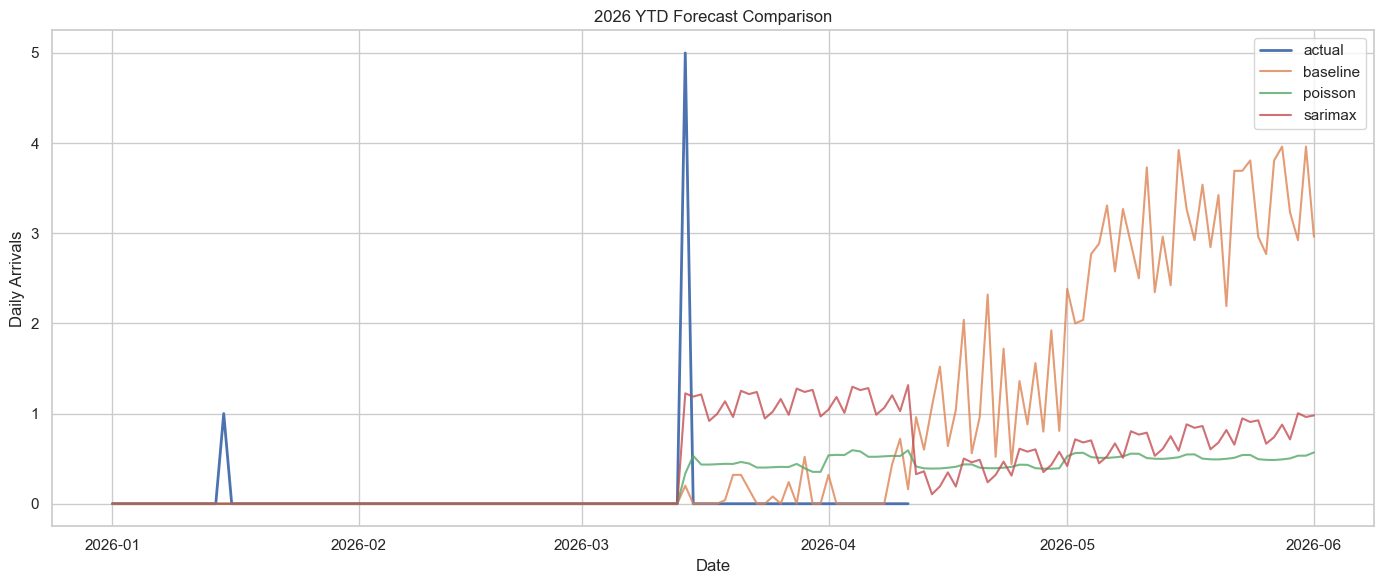

In [43]:
plt.figure(figsize=(14, 6))
plt.plot(comparison["admission_date"], comparison["arrivals"], label="actual", linewidth=2)
plt.plot(comparison["admission_date"], comparison["baseline_pred"], label="baseline", alpha=0.8)
plt.plot(comparison["admission_date"], comparison["poisson_pred"], label="poisson", alpha=0.8)
plt.plot(comparison["admission_date"], comparison["sarimax_pred"], label="sarimax", alpha=0.8)
plt.title("2026 YTD Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Daily Arrivals")
plt.legend()
plt.tight_layout()
plt.show()

## Forecast Plot

This chart is the visual version of the comparison table above. The main thing I'm checking here is timing: who ramps up first, who stays conservative, and who looks a little too eager.


In [44]:
save_csv(stat_results, "statistical_model_metrics.csv")
save_csv(comparison, "statistical_model_predictions.csv")

WindowsPath('C:/Users/Owner/PycharmProjects/opos_prediction/data/processed/statistical_model_predictions.csv')